ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](https://github.com/hebaOrhb/00-Setup-Git/blob/master/img/step2.png?raw=1)

In this lab, we will apply practical preprocessing techniques step by step.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [29]:
df.duplicated().sum()

np.int64(0)

## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column. For example:

- Age should be numeric
- Sleep Duration should be numeric
- Gender should be categorical

In [3]:
df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


We observe that most columns have appropriate data types.

Numerical features such as Age, Sleep Duration, Heart Rate, and Daily Steps should be numeric for proper analysis.

Categorical features such as Gender, Occupation, and Sleep Disorder are stored as object type, which is appropriate for categorical data.

### 2.2 Convert Incorrect Data Types

Some columns may need conversion into more suitable formats for analysis.

For example:
- Blood Pressure can be split into systolic and diastolic numeric values
- Sleep Disorder and Gender can remain categorical variables

In [4]:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)

df['Systolic BP'] = pd.to_numeric(df['Systolic BP'])
df['Diastolic BP'] = pd.to_numeric(df['Diastolic BP'])

df.dtypes

,0
Person ID,int64
Gender,object
Age,int64
Occupation,object
Sleep Duration,float64
Quality of Sleep,int64
Physical Activity Level,int64
Stress Level,int64
BMI Category,object
Blood Pressure,object


The Blood Pressure column was originally stored as text values such as "120/80".

It was separated into:
- Systolic BP
- Diastolic BP

Both columns were converted into numeric format to support statistical analysis and machine learning preprocessing.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and may affect machine learning model performance.

In [5]:
df.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


The output shows that there are no missing values in the dataset.

All columns contain complete data, which improves data quality and reduces preprocessing complexity.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

we will be running this line:

`df_missing.loc[0:5, 'Sleep Duration'] = np.nan`


- `df_missing`: The pandas DataFrame being modified.

- `.loc[0:5, 'Sleep Duration']`: This uses the label-based indexer to select specific rows and columns.

- `0:5`: Selects rows with index labels 0, 1, 2, 3, 4, and 5. In label-based indexing, the end index is inclusive.

- `'Sleep Duration'`: Selects the Sleep Duration column.

- `= np.nan`: Assigns the value np.nan (which stands for "Not a Number") to all the selected cells. This is the standard way to represent missing or null values in numerical columns in pandas. The column's data type will be converted to float

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'Sleep Duration'] = np.nan
df_missing.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,6
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


The dataset originally contained missing values in the Sleep Disorder column.

Additionally, artificial missing values were introduced into the Sleep Duration column for preprocessing demonstration purposes.

Now the Sleep Duration column contains artificial missing values for preprocessing demonstration purposes.

In [9]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (374, 15)
After removing some values:  (374, 15)


In [8]:
df_missing.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,NaN,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,NaN,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,NaN,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,NaN,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,NaN,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,NaN,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [10]:
df_removed = df_missing.dropna()
df_removed.shape

(152, 15)

In [11]:
df_removed.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


The dataset now contains fewer rows after removing records with missing values.

This strategy is suitable when only a small number of records contain missing data.

However, removing too many rows may reduce the amount of useful information available for analysis.

### Strategy 2: Mean Imputation

![Mean.png](img\Mean.png)

Mean imputation replaces missing values with the average value of the column.

It is commonly used for numerical data.

In [12]:
df_missing.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,NaN,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,NaN,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,NaN,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,NaN,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,NaN,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,NaN,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80


In [13]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Sleep Duration'].mean()

df_imputed_mean['Sleep Duration'] = df_imputed_mean['Sleep Duration'].fillna(mean_value)

df_imputed_mean.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [14]:
df_imputed_mean.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,7.15,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,7.15,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,7.15,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,7.15,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,7.15,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,7.15,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.30,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.80,7,75,6,Normal,120/80,70,8000,NaN,120,80


The missing values in the Sleep Duration column were replaced using the mean value.

This method preserves the dataset size and is suitable for numerical features.

### Strategy 3: Median Imputation

Median imputation was applied to replace missing values in the Sleep Duration column.

The median is more robust to outliers than the mean and works well with skewed numerical data.

In [15]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Sleep Duration'].median()

df_imputed_median['Sleep Duration'] = df_imputed_median['Sleep Duration'].fillna(median_value)

df_imputed_median.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [16]:
df_imputed_median.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,7.2,6,42,6,Overweight,126/83,77,4200,NaN,126,83
1,2,Male,28,Doctor,7.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
2,3,Male,28,Doctor,7.2,6,60,8,Normal,125/80,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,7.2,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,7.2,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,7.2,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN,120,80


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.



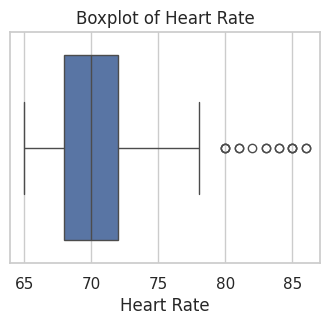

In [17]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['Heart Rate'])
plt.title("Boxplot of Heart Rate")
plt.show()

Points outside the whiskers represent potential outliers. Extreme heart rate values may affect model performance..

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [18]:
Q1 = df['Heart Rate'].quantile(0.25)
Q3 = df['Heart Rate'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Heart Rate'] < lower) | (df['Heart Rate'] > upper)]
outliers.head(15)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia,140,90
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea,132,87
18,19,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Insomnia,132,87
80,81,Female,34,Scientist,5.8,4,32,8,Overweight,131/86,81,5200,Sleep Apnea,131,86
81,82,Female,34,Scientist,5.8,4,32,8,Overweight,131/86,81,5200,Sleep Apnea,131,86
93,94,Male,35,Lawyer,7.4,7,60,5,Obese,135/88,84,3300,Sleep Apnea,135,88
145,146,Female,38,Lawyer,7.4,7,60,5,Obese,135/88,84,3300,Sleep Apnea,135,88


The output displays records considered extreme based on statistical boundaries.
These may be valid extreme health records or potential data errors.

### Remove Outliers
We remove values outside the acceptable range.

In [19]:
df_no_outliers = df[(df['Heart Rate'] >= lower) & (df['Heart Rate'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (374, 15)
After removing outliers: (359, 15)


# The dataset size is slightly reduced after removing extreme Heart Rate values.

Removing outliers can reduce distortion and improve model performance, but excessive removal may eliminate useful rare observations.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent real-world health conditions or unusual sleep patterns.

Before removing outliers, we should determine whether the value is:
- A data entry error
- Or a valid but rare observation

### Capping Outliers (Percentile Method)
Instead of removing outliers, extreme Heart Rate values can be capped using percentile limits.

In [20]:
lower_cap = df['Heart Rate'].quantile(0.05)
upper_cap = df['Heart Rate'].quantile(0.95)

df_capped = df.copy()

df_capped['Heart Rate'] = df_capped['Heart Rate'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [21]:
df[['Age', 'Heart Rate']].head()

,Age,Heart Rate
0,27,77
1,28,75
2,28,75
3,28,85
4,28,85


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['Age', 'Heart Rate']].copy()

df_scaled[['Age', 'Heart Rate']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Age,Heart Rate
0,0.00000,0.571429
1,0.03125,0.476190
2,0.03125,0.476190
3,0.03125,0.952381
4,0.03125,0.952381


After applying Min-Max normalization rescales Age and Heart Rate values between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
If one record originally had a higher value than another, it will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:


This method keeps the shape of the distribution but rescales it around zero.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['Age', 'Heart Rate']].copy()

df_standardized[['Age', 'Heart Rate']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Age,Heart Rate
0,-1.753096,1.654719
1,-1.637643,1.170474
2,-1.637643,1.170474
3,-1.637643,3.591698
4,-1.637643,3.591698


After standardization, the Age and Heart Rate features are centered around 0.

Values above the mean become positive, while values below the mean become negative.

The standard deviation becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

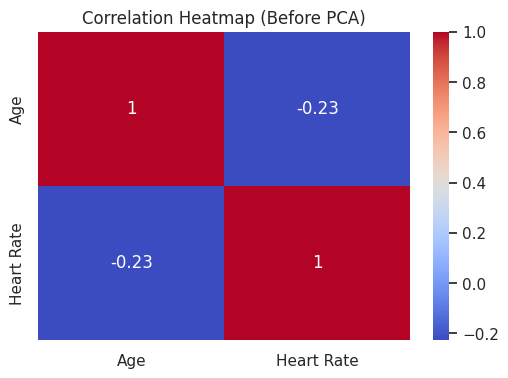

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df_standardized[['Age', 'Heart Rate']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (Before PCA)")

plt.show()

The heatmap shows the correlation between Age and Heart Rate.

- Values close to 1 indicate strong positive correlation
- Values close to -1 indicate strong negative correlation
- Values close to 0 indicate weak linear relationship

A correlation value close to 0 indicates that there is almost **NO linear** relationship between the two features.

This means that Age and Heart Rate do not move together in a predictable linear pattern.

Since PCA is most useful when features are strongly correlated,
the benefit of dimensionality reduction in this case may be limited.

Therefore, applying PCA here is mainly for demonstration purposes rather than necessity.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Age
X2 = Heart Rate

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [25]:
from sklearn.decomposition import PCA

X = df_standardized[['Age', 'Heart Rate']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.6128031 0.3871969]


The Explained Variance Ratio shows how much information is captured by each principal component.


> If the first principal component captures most of the variance, dimensionality reduction is considered effective.



For example:
- If PC1 explains 85% of the variance, it means that one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

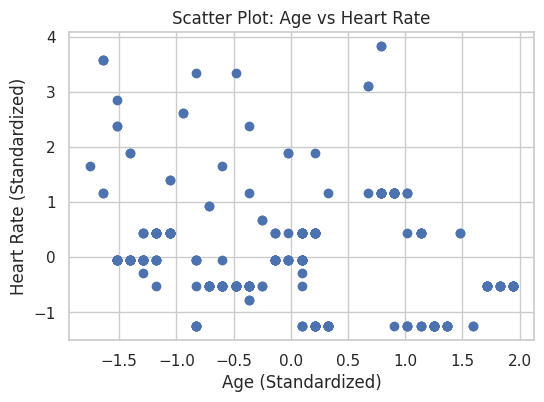

In [26]:
##In addition to the heatmap, we can visualize the relationship between two features using a scatter plot.
##A scatter plot allows us to observe whether the features exhibit a linear pattern, meaning whether they increase or decrease together in a consistent way.

plt.figure(figsize=(6,4))

plt.scatter(df_standardized['Age'], df_standardized['Heart Rate'])

plt.xlabel("Age (Standardized)")
plt.ylabel("Heart Rate (Standardized)")

plt.title("Scatter Plot: Age vs Heart Rate")

plt.show()

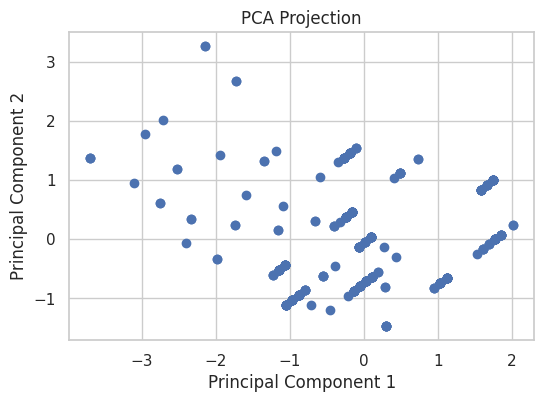

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one record from the sleep dataset.

The axes no longer represent the original features (Age and Heart Rate).

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction indicates how much variation is captured by PC1.
If most of the spread appears horizontally, it suggests that PC1 captures most of the dataset's information.

This projection allows us to visualize high-dimensional data in a lower-dimensional space.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2